### **Description**

NEMO Cookbook extends the familiar xarray data model with grid-aware data structures designed for performing reproducible analyses of the Nucleus for European Modelling of the Ocean ([**NEMO**](https://www.nemo-ocean.eu/)) ocean general circulation model outputs.

This recipe introduces the fundamentals of the `NEMODataTree` and `NEMODataArray` objects, including:

* Constructing a `NEMODataTree` directly from netCDF files.

* Navigating NEMO ocean and sea-ice variables stored in a `NEMODataTree`.

* Basic properties of a `NEMODataArray`.

* Geographical plotting using `NEMODataArray`.

* Performing grid-aware operations using `NEMODataArray`.

---

In [2]:
# -- Import required packages -- #
import cartopy.crs as ccrs
import pandas as pd
import xarray as xr

import nemo_cookbook as ncb
from nemo_cookbook import NEMODataTree

xr.set_options(display_style="text")

##### **Creating a NEMODataTree from Local Files**

* We'll begin by creating a simple `NEMODataTree` using local NEMO model output files from the `AGRIF_DEMO` reference configuration.

---

`AGRIF_DEMO`

* `AGRIF_DEMO` is based on the `ORCA2_ICE_PISCES` global reference configuration with the inclusion of 3 online nested domains.

* Here, we will only consider the 2° global parent domain.

* **NEMO Cookbook** includes a subset of the `AGRIF_DEMO` model outputs made accessible via cloud object storage.

* Further information on this reference configuration can be found [**here**](https://sites.nemo-ocean.io/user-guide/cfgs.html#agrif-demo).

---

* Let's download and collect the filepaths for the `AGRIF_DEMO` configuration using the `nemo_cookbook.examples.get_filepaths()` convenience function, which caches and generates local filepaths for available NEMO reference configurations:

In [3]:
filepaths = ncb.examples.get_filepaths("AGRIF_DEMO")
filepaths

{'domain_cfg.nc': '/Users/otooth/Library/Caches/nemo_cookbook/AGRIF_DEMO/domain_cfg.nc',
 '2_domain_cfg.nc': '/Users/otooth/Library/Caches/nemo_cookbook/AGRIF_DEMO/2_domain_cfg.nc',
 '3_domain_cfg.nc': '/Users/otooth/Library/Caches/nemo_cookbook/AGRIF_DEMO/3_domain_cfg.nc',
 'ORCA2_5d_00010101_00010110_grid_T.nc': '/Users/otooth/Library/Caches/nemo_cookbook/AGRIF_DEMO/ORCA2_5d_00010101_00010110_grid_T.nc',
 'ORCA2_5d_00010101_00010110_grid_U.nc': '/Users/otooth/Library/Caches/nemo_cookbook/AGRIF_DEMO/ORCA2_5d_00010101_00010110_grid_U.nc',
 'ORCA2_5d_00010101_00010110_grid_V.nc': '/Users/otooth/Library/Caches/nemo_cookbook/AGRIF_DEMO/ORCA2_5d_00010101_00010110_grid_V.nc',
 'ORCA2_5d_00010101_00010110_grid_W.nc': '/Users/otooth/Library/Caches/nemo_cookbook/AGRIF_DEMO/ORCA2_5d_00010101_00010110_grid_W.nc',
 'ORCA2_5d_00010101_00010110_icemod.nc': '/Users/otooth/Library/Caches/nemo_cookbook/AGRIF_DEMO/ORCA2_5d_00010101_00010110_icemod.nc',
 '2_Nordic_5d_00010101_00010110_grid_T.nc': '/User

* We can create a `NEMODataTree` from a dictionary of paths to local netCDF files using the `.from_paths()` constructor:

---

`from_paths()`

* Creates a `NEMODataTree` from a dictionary of paths to NEMO model outputs files organised into a hierarchy (e.g., `parent`, `child` `grandchild`) of NEMO model grids (e.g., `gridT`, `gridU`, etc.):
```
    <xarray.DataTree 'nemo'>
    Group: /
    ├── Group: /gridT
    ├── Group: /gridU
    ├── Group: /gridV
    ├── Group: /gridW
    └── Group: /gridF
```

where the `gridT` node contains time series of scalar variables stored in the `...grid_T.nc` files in a single `xarray.Dataset` and so on.

---

* Let's start by defining the `paths` dictionary, which contains the filepaths corresponding to our global parent domain.

* We populate the `parent` dictionary with the filepaths to the `domain_cfg` and `gridT/U/V/W` netCDF files produced for the `AGRIF_DEMO` (ORCA2) parent domain. 

In [4]:
paths = {"parent": {"domain": filepaths["domain_cfg.nc"],
                    "gridT": filepaths["ORCA2_5d_00010101_00010110_grid_T.nc"],
                    "gridU": filepaths["ORCA2_5d_00010101_00010110_grid_U.nc"],
                    "gridV": filepaths["ORCA2_5d_00010101_00010110_grid_V.nc"],
                    "gridW": filepaths["ORCA2_5d_00010101_00010110_grid_W.nc"],
                    "icemod": filepaths["ORCA2_5d_00010101_00010110_icemod.nc"]
                    },
         }

* We can now construct a new `NEMODataTree` using the `.from_paths()` constructor.

* **Note that we also need to specify that our global parent domain is zonally periodic (`iperio=True`) and north folding on T-points (`nftype = "T"`) rather than a closed (regional) domain.**

In [5]:
nemo = NEMODataTree.from_paths(paths, iperio=True, nftype="T", chunks={})

nemo

<xarray.DataTree 'NEMO model'>
Group: /
│   Dimensions:               (time_counter: 2, axis_nbounds: 2, ncatice: 5)
│   Coordinates:
│     * time_counter          (time_counter) object 16B 0001-01-03 12:00:00 0001-...
│       time_centered         (time_counter) object 16B dask.array<chunksize=(1,), meta=np.ndarray>
│       time_instant          (time_counter) object 16B dask.array<chunksize=(1,), meta=np.ndarray>
│     * ncatice               (ncatice) float32 20B 1.0 2.0 3.0 4.0 5.0
│   Dimensions without coordinates: axis_nbounds
│   Data variables:
│       time_centered_bounds  (time_counter, axis_nbounds) object 32B dask.array<chunksize=(1, 2), meta=np.ndarray>
│       time_counter_bounds   (time_counter, axis_nbounds) object 32B dask.array<chunksize=(1, 2), meta=np.ndarray>
│       time_instant_bounds   (time_counter, axis_nbounds) object 32B dask.array<chunksize=(1, 2), meta=np.ndarray>
│   Attributes:
│       nftype:   T
│       iperio:   True
├── Group: /gridT
│       Dimensions:               (k: 31, axis_nbounds: 2, time_counter: 2, j: 148,
│                                  i: 180, ncatice: 5)
│       Coordinates:
│         * k                     (k) int64 248B 1 2 3 4 5 6 7 ... 25 26 27 28 29 30 31
│         * deptht                (k) float32 124B 5.0 15.0 25.0 ... 4.75e+03 5.25e+03
│           time_centered         (time_counter) object 16B dask.array<chunksize=(1,), meta=np.ndarray>
│           time_instant          (time_counter) object 16B dask.array<chunksize=(1,), meta=np.ndarray>
│         * j                     (j) int64 1kB 1 2 3 4 5 6 ... 143 144 145 146 147 148
│         * i                     (i) int64 1kB 1 2 3 4 5 6 ... 175 176 177 178 179 180
│           gphit                 (j, i) float64 213kB ...
│           glamt                 (j, i) float64 213kB ...
│       Dimensions without coordinates: axis_nbounds
│       Data variables: (12/85)
│           deptht_bounds         (k, axis_nbounds) float32 248B dask.array<chunksize=(31, 2), meta=np.ndarray>
│           time_centered_bounds  (time_counter, axis_nbounds) object 32B dask.array<chunksize=(1, 2), meta=np.ndarray>
│           time_counter_bounds   (time_counter, axis_nbounds) object 32B dask.array<chunksize=(1, 2), meta=np.ndarray>
│           time_instant_bounds   (time_counter, axis_nbounds) object 32B dask.array<chunksize=(1, 2), meta=np.ndarray>
│           e3t                   (time_counter, k, j, i) float32 7MB dask.array<chunksize=(1, 31, 148, 180), meta=np.ndarray>
│           thetao                (time_counter, k, j, i) float32 7MB dask.array<chunksize=(1, 31, 148, 180), meta=np.ndarray>
│           ...                    ...
│           sisalcat              (time_counter, ncatice, j, i) float32 1MB dask.array<chunksize=(1, 5, 148, 180), meta=np.ndarray>
│           sitemcat              (time_counter, ncatice, j, i) float32 1MB dask.array<chunksize=(1, 5, 148, 180), meta=np.ndarray>
│           e1t                   (j, i) float64 213kB ...
│           e2t                   (j, i) float64 213kB ...
│           tmask                 (k, j, i) bool 826kB False False False ... False False
│           tmaskutil             (j, i) bool 27kB False False False ... False False
│       Attributes:
│           name:         ORCA2_5d_00010101_00010110_grid_T
│           description:  ocean T grid variables
│           title:        ocean T grid variables
│           Conventions:  CF-1.6
│           timeStamp:    2025-Sep-13 17:44:13 GMT
│           uuid:         92bd7786-afa1-44db-8a63-995c0e56d322
│           nftype:       T
│           iperio:       True
├── Group: /gridU
│       Dimensions:               (k: 31, axis_nbounds: 2, time_counter: 2, j: 148,
│                                  i: 180)
│       Coordinates:
│         * k                     (k) int64 248B 1 2 3 4 5 6 7 ... 25 26 27 28 29 30 31
│         * depthu                (k) float32 124B 5.0 15.0 25.0 ... 4.75e+03 5.25e+03
│           time_centered         (time_counter

#### **Navigating a NEMODataTree**
---

* Now we have created an example `NEMODataTree`, let's take a closer look at its contents and how to access NEMO model output variables.

* We'll start by looking at the nodes in our `NEMODataTree`:

In [6]:
nemo.groups

('/', '/gridT', '/gridU', '/gridV', '/gridW', '/gridF')

**Some Important Points:**

* A `NEMODataTree` does not have a `domain` node since grid scale factors and masks associated with each model domain are assigned to their respective grid nodes during pre-processing (e.g., horizontal grid scale factors `e1t` and `e2t` are stored in `gridT` etc.).

* During the construction of a `NEMODataTree`, the standard (`depth{p}`, `y`, `x`) dimensions of NEMO model outputs (where `p` is the grid point type) are transformed to NEMO grid indices (**i**, **j**, **k**). This has two important implications:

    * `xarray.Datasets` stored in each grid node share the same coordinate dimension names (`i`, `j`, `k`), but are staggered according to the location of variables on the NEMO model grid.

    * All grid indices use Fortran (1-based) indexing to be consistent with the original NEMO model code.

    | Grid Type    | Grid Indices                 |
    | -----------  | --------------------------   |
    | `T`          | $(i, j, k)$                    |
    | `U`          | $(i + \frac{1}{2}, j, k)$              |
    | `V`          | $(i, j + \frac{1}{2}, k)$              |
    | `W`          | $(i, j, k + \frac{1}{2})$              |
    | `F`          | $(i + \frac{1}{2}, j + \frac{1}{2}, k)$        |

---

* To see what this means in practice, we will consider the `gridT` and `gridU` nodes of the 2° `AGRIF_DEMO` `NEMODataTree` below:

In [7]:
nemo['gridT']

<xarray.DataTree 'gridT'>
Group: /gridT
    Dimensions:               (time_counter: 2, axis_nbounds: 2, ncatice: 5, k: 31,
                               j: 148, i: 180)
    Coordinates:
      * k                     (k) int64 248B 1 2 3 4 5 6 7 ... 25 26 27 28 29 30 31
      * deptht                (k) float32 124B 5.0 15.0 25.0 ... 4.75e+03 5.25e+03
        time_centered         (time_counter) object 16B dask.array<chunksize=(1,), meta=np.ndarray>
        time_instant          (time_counter) object 16B dask.array<chunksize=(1,), meta=np.ndarray>
      * j                     (j) int64 1kB 1 2 3 4 5 6 ... 143 144 145 146 147 148
      * i                     (i) int64 1kB 1 2 3 4 5 6 ... 175 176 177 178 179 180
        gphit                 (j, i) float64 213kB ...
        glamt                 (j, i) float64 213kB ...
    Inherited coordinates:
      * time_counter          (time_counter) object 16B 0001-01-03 12:00:00 0001-...
      * ncatice               (ncatice) float32 20B 1.0 2.0 3.0 4.0 5.0
    Dimensions without coordinates: axis_nbounds
    Data variables: (12/85)
        deptht_bounds         (k, axis_nbounds) float32 248B dask.array<chunksize=(31, 2), meta=np.ndarray>
        time_centered_bounds  (time_counter, axis_nbounds) object 32B dask.array<chunksize=(1, 2), meta=np.ndarray>
        time_counter_bounds   (time_counter, axis_nbounds) object 32B dask.array<chunksize=(1, 2), meta=np.ndarray>
        time_instant_bounds   (time_counter, axis_nbounds) object 32B dask.array<chunksize=(1, 2), meta=np.ndarray>
        e3t                   (time_counter, k, j, i) float32 7MB dask.array<chunksize=(1, 31, 148, 180), meta=np.ndarray>
        thetao                (time_counter, k, j, i) float32 7MB dask.array<chunksize=(1, 31, 148, 180), meta=np.ndarray>
        ...                    ...
        sisalcat              (time_counter, ncatice, j, i) float32 1MB dask.array<chunksize=(1, 5, 148, 180), meta=np.ndarray>
        sitemcat              (time_counter, ncatice, j, i) float32 1MB dask.array<chunksize=(1, 5, 148, 180), meta=np.ndarray>
        e1t                   (j, i) float64 213kB ...
        e2t                   (j, i) float64 213kB ...
        tmask                 (k, j, i) bool 826kB False False False ... False False
        tmaskutil             (j, i) bool 27kB False False False ... False False
    Attributes:
        name:         ORCA2_5d_00010101_00010110_grid_T
        description:  ocean T grid variables
        title:        ocean T grid variables
        Conventions:  CF-1.6
        timeStamp:    2025-Sep-13 17:44:13 GMT
        uuid:         92bd7786-afa1-44db-8a63-995c0e56d322
        nftype:       T
        iperio:       True

In [8]:
nemo['gridU']

<xarray.DataTree 'gridU'>
Group: /gridU
    Dimensions:               (time_counter: 2, axis_nbounds: 2, ncatice: 5, k: 31,
                               j: 148, i: 180)
    Coordinates:
      * k                     (k) int64 248B 1 2 3 4 5 6 7 ... 25 26 27 28 29 30 31
      * depthu                (k) float32 124B 5.0 15.0 25.0 ... 4.75e+03 5.25e+03
        time_centered         (time_counter) object 16B dask.array<chunksize=(1,), meta=np.ndarray>
        time_instant          (time_counter) object 16B dask.array<chunksize=(1,), meta=np.ndarray>
      * j                     (j) int64 1kB 1 2 3 4 5 6 ... 143 144 145 146 147 148
      * i                     (i) float64 1kB 1.5 2.5 3.5 4.5 ... 178.5 179.5 180.5
        gphiu                 (j, i) float64 213kB ...
        glamu                 (j, i) float64 213kB ...
    Inherited coordinates:
      * time_counter          (time_counter) object 16B 0001-01-03 12:00:00 0001-...
      * ncatice               (ncatice) float32 20B 1.0 2.0 3.0 4.0 5.0
    Dimensions without coordinates: axis_nbounds
    Data variables: (12/15)
        depthu_bounds         (k, axis_nbounds) float32 248B dask.array<chunksize=(31, 2), meta=np.ndarray>
        time_centered_bounds  (time_counter, axis_nbounds) object 32B dask.array<chunksize=(1, 2), meta=np.ndarray>
        time_counter_bounds   (time_counter, axis_nbounds) object 32B dask.array<chunksize=(1, 2), meta=np.ndarray>
        time_instant_bounds   (time_counter, axis_nbounds) object 32B dask.array<chunksize=(1, 2), meta=np.ndarray>
        e3u                   (time_counter, k, j, i) float32 7MB dask.array<chunksize=(1, 31, 148, 180), meta=np.ndarray>
        uos                   (time_counter, j, i) float32 213kB dask.array<chunksize=(1, 148, 180), meta=np.ndarray>
        ...                    ...
        sozohetr              (time_counter, j, i) float32 213kB dask.array<chunksize=(1, 148, 180), meta=np.ndarray>
        sozosatr              (time_counter, j, i) float32 213kB dask.array<chunksize=(1, 148, 180), meta=np.ndarray>
        e1u                   (j, i) float64 213kB ...
        e2u                   (j, i) float64 213kB ...
        umask                 (k, j, i) bool 826kB False False False ... False False
        umaskutil             (j, i) bool 27kB False False False ... False False
    Attributes:
        name:         ORCA2_5d_00010101_00010110_grid_U
        description:  ocean U grid variables
        title:        ocean U grid variables
        Conventions:  CF-1.6
        timeStamp:    2025-Sep-13 17:44:14 GMT
        uuid:         8419ec9a-fab7-426e-ad53-3d601ef04eb8
        nftype:       T
        iperio:       True

* Above, we have seen how to access the nodes in an `NEMODataTree` using a dictionary-like syntax.

* We can also extend this to include output variables stored in given grid node as follows...

* To access an **unmasked** variable (i.e., unchanged from the original model output files) as an `xarray.DataArray`:

In [9]:
nemo['gridT']['thetao']

<xarray.DataArray 'thetao' (time_counter: 2, k: 31, j: 148, i: 180)> Size: 7MB
dask.array<open_dataset-thetao, shape=(2, 31, 148, 180), dtype=float32, chunksize=(1, 31, 148, 180), chunktype=numpy.ndarray>
Coordinates:
  * time_counter   (time_counter) object 16B 0001-01-03 12:00:00 0001-01-08 1...
    time_centered  (time_counter) object 16B dask.array<chunksize=(1,), meta=np.ndarray>
    time_instant   (time_counter) object 16B dask.array<chunksize=(1,), meta=np.ndarray>
  * k              (k) int64 248B 1 2 3 4 5 6 7 8 9 ... 24 25 26 27 28 29 30 31
  * deptht         (k) float32 124B 5.0 15.0 25.0 ... 4.75e+03 5.25e+03
  * j              (j) int64 1kB 1 2 3 4 5 6 7 8 ... 142 143 144 145 146 147 148
  * i              (i) int64 1kB 1 2 3 4 5 6 7 8 ... 174 175 176 177 178 179 180
    gphit          (j, i) float64 213kB ...
    glamt          (j, i) float64 213kB ...
Attributes:
    standard_name:       sea_water_potential_temperature
    long_name:           temperature
    units:               degC
    online_operation:    instant
    interval_operation:  5 d
    interval_write:      5 d
    cell_methods:        time: point

* To access a **unmasked** variable as a `NEMODataArray` (i.e.,  NEMO grid-aware extension of `xarray.DataArray`), we can instead provide a direct path to the variable:

In [10]:
nemo["gridT/thetao"]

<NEMODataTree 'NEMO model'>
  <NEMODataArray 'thetao' (Domain: '.', Grid: 'gridT', Grid Type: 'T')>

<xarray.DataArray 'thetao' (time_counter: 2, k: 31, j: 148, i: 180)> Size: 7MB
dask.array<open_dataset-thetao, shape=(2, 31, 148, 180), dtype=float32, chunksize=(1, 31, 148, 180), chunktype=numpy.ndarray>
Coordinates:
  * time_counter   (time_counter) object 16B 0001-01-03 12:00:00 0001-01-08 1...
    time_centered  (time_counter) object 16B dask.array<chunksize=(1,), meta=np.ndarray>
    time_instant   (time_counter) object 16B dask.array<chunksize=(1,), meta=np.ndarray>
  * k              (k) int64 248B 1 2 3 4 5 6 7 8 9 ... 24 25 26 27 28 29 30 31
  * deptht         (k) float32 124B 5.0 15.0 25.0 ... 4.75e+03 5.25e+03
  * j              (j) int64 1kB 1 2 3 4 5 6 7 8 ... 142 143 144 145 146 147 148
  * i              (i) int64 1kB 1 2 3 4 5 6 7 8 ... 174 175 176 177 178 179 180
    gphit          (j, i) float64 213kB ...
    glamt          (j, i) float64 213kB ...
Attributes:
    standard_name:       sea_water_potential_temperature
    long_name:           temperature
    units:               degC
    online_operation:    instant
    interval_operation:  5 d
    interval_write:      5 d
    cell_methods:        time: point

* To access a **masked** (i.e., the appropriate land-sea mask is applied automatically) variable as an `NEMODataArray`, we can instead provide a direct path to the variable:

In [11]:
nemo["gridT/thetao"].masked

<NEMODataTree 'NEMO model'>
  <NEMODataArray 'thetao' (Domain: '.', Grid: 'gridT', Grid Type: 'T')>

<xarray.DataArray 'thetao' (time_counter: 2, k: 31, j: 148, i: 180)> Size: 7MB
dask.array<where, shape=(2, 31, 148, 180), dtype=float32, chunksize=(1, 31, 148, 180), chunktype=numpy.ndarray>
Coordinates:
  * time_counter   (time_counter) object 16B 0001-01-03 12:00:00 0001-01-08 1...
    time_centered  (time_counter) object 16B dask.array<chunksize=(1,), meta=np.ndarray>
    time_instant   (time_counter) object 16B dask.array<chunksize=(1,), meta=np.ndarray>
  * k              (k) int64 248B 1 2 3 4 5 6 7 8 9 ... 24 25 26 27 28 29 30 31
  * deptht         (k) float32 124B 5.0 15.0 25.0 ... 4.75e+03 5.25e+03
  * j              (j) int64 1kB 1 2 3 4 5 6 7 8 ... 142 143 144 145 146 147 148
  * i              (i) int64 1kB 1 2 3 4 5 6 7 8 ... 174 175 176 177 178 179 180
    gphit          (j, i) float64 213kB -78.19 -78.19 -78.19 ... 51.2 50.53
    glamt          (j, i) float64 213kB 80.0 82.0 84.0 86.0 ... 80.0 80.0 80.0
Attributes:
    standard_name:       sea_water_potential_temperature
    long_name:           temperature
    units:               degC
    online_operation:    instant
    interval_operation:  5 d
    interval_write:      5 d
    cell_methods:        time: point

#### **NEMODataTree Grid Properties**
---

* We often need access to variables describing the NEMO ocean model domain to calculate derived quantities, such as volume, heat and salt transports.

* For convenience, the `NEMODataTree` class includes methods for calculating grid cell areas and volumes.

* For example, to compute the horizontal area of grid cells centered on T-points in the parent domain, we can use the `.cell_area()` method:

---

`cell_area()`

* The `dim` argument represents the dimensional orthogonal to the grid cell area to be computed.

* For **T** grid points, this results in the following grid cell areas: 

    | dim   | Grid Cell Area           |
    | ----------- | ---------------------- |
    | `i`         | e2t * e3t             |
    | `j`         | e1t * e3t        |
    | `k`         | e1t * e2t        |

---

In [12]:
nemo.cell_area(grid="gridT", dim="k")

<xarray.DataArray 'areacello' (j: 148, i: 180)> Size: 213kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(148, 180))
Coordinates:
  * j        (j) int64 1kB 1 2 3 4 5 6 7 8 9 ... 141 142 143 144 145 146 147 148
  * i        (i) int64 1kB 1 2 3 4 5 6 7 8 9 ... 173 174 175 176 177 178 179 180
    gphit    (j, i) float64 213kB -78.19 -78.19 -78.19 ... 51.91 51.2 50.53
    glamt    (j, i) float64 213kB 80.0 82.0 84.0 86.0 ... 80.0 80.0 80.0 80.0

* Next, let's compute the volume of each grid cell centered on a T grid point in the model parent domain using the `.cell_volume()` method:

In [13]:
nemo.cell_volume(grid="gridT")

<xarray.DataArray 'volcello' (time_counter: 2, k: 31, j: 148, i: 180)> Size: 13MB
dask.array<mul, shape=(2, 31, 148, 180), dtype=float64, chunksize=(1, 31, 148, 180), chunktype=numpy.ndarray>
Coordinates:
  * time_counter   (time_counter) object 16B 0001-01-03 12:00:00 0001-01-08 1...
    time_centered  (time_counter) object 16B dask.array<chunksize=(1,), meta=np.ndarray>
    time_instant   (time_counter) object 16B dask.array<chunksize=(1,), meta=np.ndarray>
  * k              (k) int64 248B 1 2 3 4 5 6 7 8 9 ... 24 25 26 27 28 29 30 31
  * deptht         (k) float32 124B 5.0 15.0 25.0 ... 4.75e+03 5.25e+03
  * j              (j) int64 1kB 1 2 3 4 5 6 7 8 ... 142 143 144 145 146 147 148
  * i              (i) int64 1kB 1 2 3 4 5 6 7 8 ... 174 175 176 177 178 179 180
    gphit          (j, i) float64 213kB -78.19 -78.19 -78.19 ... 51.2 50.53
    glamt          (j, i) float64 213kB 80.0 82.0 84.0 86.0 ... 80.0 80.0 80.0
Attributes:
    standard_name:       cell_thickness
    long_name:           T-cell thickness
    units:               m
    online_operation:    average
    interval_operation:  10800 s
    interval_write:      5 d
    cell_methods:        time: mean (interval: 10800 s)

#### **NEMODataArray Properties**
---

* In addition to simply storing ocean model output variable, a `NEMODataArray` also gives each variable knowledge of its:

    - NEMO model grid location (e.g., T, U, V, W, F)
    - parent `NEMODataTree`
    - associated NEMO grid metrics (grid scale factors)

--- 

* Each `NEMODataArray` has several key properties to support grid-aware computation...

    - `.data`  Underlying xarray.DataArray of the NEMO output variable.

    - `.grid`  Path to NEMO model grid node where variable is stored.

    - `.grid_type`  Type of NEMO model grid where variable is defined.

    - `.metrics`  Dictionary of NEMO model grid scale factors (e.g., e1t, e2t etc.) associated with the variable.

    - `.mask`  Variable land-sea mask (xarray.DataArray).

    - `.masked`  Returns variable NEMODataArray with land-sea mask applied.


In [14]:
# Collect grid scale factors of sea water potential temperature (thetao) variable on T-grid:
nemo['gridT/thetao'].metrics

{'e1': <NEMODataTree 'NEMO model'>
   <NEMODataArray 'e1t' (Domain: '.', Grid: 'gridT', Grid Type: 'T')>
 
 <xarray.DataArray 'e1t' (j: 148, i: 180)> Size: 213kB
 [26640 values with dtype=float64]
 Coordinates:
   * j        (j) int64 1kB 1 2 3 4 5 6 7 8 9 ... 141 142 143 144 145 146 147 148
   * i        (i) int64 1kB 1 2 3 4 5 6 7 8 9 ... 173 174 175 176 177 178 179 180
     gphit    (j, i) float64 213kB ...
     glamt    (j, i) float64 213kB ...,
 'e2': <NEMODataTree 'NEMO model'>
   <NEMODataArray 'e2t' (Domain: '.', Grid: 'gridT', Grid Type: 'T')>
 
 <xarray.DataArray 'e2t' (j: 148, i: 180)> Size: 213kB
 [26640 values with dtype=float64]
 Coordinates:
   * j        (j) int64 1kB 1 2 3 4 5 6 7 8 9 ... 141 142 143 144 145 146 147 148
   * i        (i) int64 1kB 1 2 3 4 5 6 7 8 9 ... 173 174 175 176 177 178 179 180
     gphit    (j, i) float64 213kB ...
     glamt    (j, i) float64 213kB ...,
 'e3': <NEMODataTree 'NEMO model'>
   <NEMODataArray 'e3t' (Domain: '.', Grid: 'gridT', Grid

In [15]:
# Collect land-sea mask of sea water potential temperature (thetao) variable on T-grid:
nemo['gridT/thetao'].mask

<xarray.DataArray 'tmask' (k: 31, j: 148, i: 180)> Size: 826kB
array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
...
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]]],
      shape=(31, 148, 180))
Coordinates:
  * k        (k) int64 248B 1 2 3 4 5 6 7 8 9 10 ... 23 24 25 26 27 28 29 30 31
  * deptht   (k) float32 124B 5.0 15.0 25.0 ... 4.251e+03 4.75e+03 5.25e+03
  * j        (j) int64 1kB 1 2 3 4 5 6 7 8 9 ... 141 142 143 144 145 146 147 148
  * i        (i) int64 1kB 1 2 3 4 5 6 7 8 9 ... 173 174 175 176 177 178 179 180
    gphit    (j, i) float64 213kB ...
    glamt    (j, i) float64 213kB ...

#### **NEMODataArray Core Operations**

---

**Summary of Core Operations**

* Plotting:  `geoplot()`

* Indexing:  `sel_like()`

* Clipping & Masking:  `clip()`, `apply_mask()`

* Grid Operators:  `diff()`, `derivative()`, `integral()`, `depth_integral()`.

* Statistics:  `weighted_mean()`, `masked_statistic()`.

* Grid Transformations:  `interp_to()`, `transform_vertical_grid()`.

* For more details on the above core operations see the follow section of the [**How To... Guide**](https://noc-msm.github.io/nemo_cookbook/howto/).


#### **Plotting**

---

* Since `NEMODataArray` is a wrapper around the familiar `xarray.DataArray`, we can still access `xarray.DataArray.plot` for exploratory plotting.

* However, for geographical plots of 2-dimensional `NEMODataArrays` with dimensions (`j`, `i`) only, we can use the `geoplot()` method to produce a Cartopy `GeoQuadMesh` as follows:

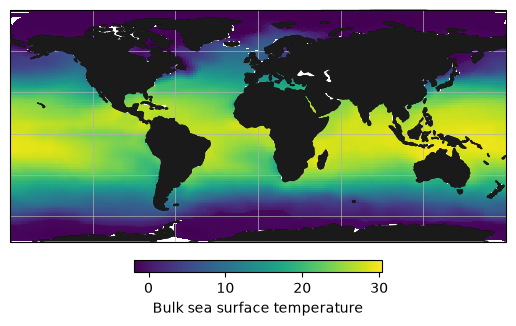

In [16]:
# -- Plot example sea surface temperature (°C) -- #
nemo["gridT/tos"].masked.isel(time_counter=0).geoplot()

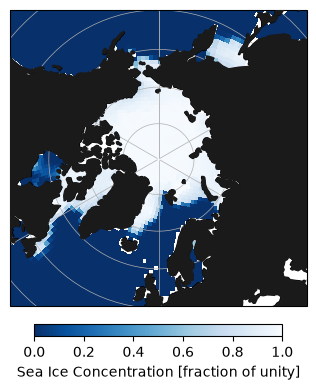

In [17]:
# -- Plot example sea ice concentration in the Northern Hemisphere -- #
proj = ccrs.NorthPolarStereo()

(nemo["gridT/siconc"]
 .isel(time_counter=0)
 .geoplot(projection=proj,
          vmin=0, vmax=1,
          extent=(-180, 180, 50, 90),
          cmap='Blues_r',
          clabel_kwargs={'label': 'Sea Ice Concentration [fraction of unity]'}
          )
 )

#### **Indexing**

---

* Alongside the more familiar `.sel()` and `.isel()` label based selection methods, the `.sel_like()` method can be used to index a `NEMODataArray` according to the dimension index labels of another `NEMODataArray` or `xarray.DataArray` as follows:

In [18]:
nda = nemo["gridT/thetao"].sel(i=slice(1, 90), k=20)

nemo["gridT/thetao"].sel_like(nda)

<NEMODataTree 'NEMO model'>
  <NEMODataArray 'thetao' (Domain: '.', Grid: 'gridT', Grid Type: 'T')>

<xarray.DataArray 'thetao' (time_counter: 2, j: 148, i: 90)> Size: 107kB
dask.array<getitem, shape=(2, 148, 90), dtype=float32, chunksize=(1, 148, 90), chunktype=numpy.ndarray>
Coordinates:
  * time_counter   (time_counter) object 16B 0001-01-03 12:00:00 0001-01-08 1...
    time_centered  (time_counter) object 16B dask.array<chunksize=(1,), meta=np.ndarray>
    time_instant   (time_counter) object 16B dask.array<chunksize=(1,), meta=np.ndarray>
  * j              (j) int64 1kB 1 2 3 4 5 6 7 8 ... 142 143 144 145 146 147 148
  * i              (i) int64 720B 1 2 3 4 5 6 7 8 9 ... 83 84 85 86 87 88 89 90
    gphit          (j, i) float64 107kB -78.19 -78.19 -78.19 ... 70.0 70.0 70.0
    glamt          (j, i) float64 107kB 80.0 82.0 84.0 ... -100.0 -100.0 -100.0
    deptht         float32 4B 520.8
    k              int64 8B 20
Attributes:
    standard_name:       sea_water_potential_temperature
    long_name:           temperature
    units:               degC
    online_operation:    instant
    interval_operation:  5 d
    interval_write:      5 d
    cell_methods:        time: point

* We can also use the `add_geoindex()` method of our `NEMODataTree` to enable indexing of a NEMO model variables with geographical coordinates:

* **Note that the `.dataset` property must be used to access the `xarray.Dataset` view of the NEMO model grid node**

In [19]:
nemo_geo = nemo.add_geoindex(grid="gridT")

nemo_geo["gridT"].dataset.sel(gphit=60, glamt=-40, method="nearest")

<xarray.Dataset> Size: 2kB
Dimensions:               (k: 31, axis_nbounds: 2, time_counter: 2, ncatice: 5)
Coordinates:
  * k                     (k) int64 248B 1 2 3 4 5 6 7 ... 25 26 27 28 29 30 31
  * deptht                (k) float32 124B 5.0 15.0 25.0 ... 4.75e+03 5.25e+03
  * time_counter          (time_counter) object 16B 0001-01-03 12:00:00 0001-...
    time_centered         (time_counter) object 16B dask.array<chunksize=(1,), meta=np.ndarray>
    time_instant          (time_counter) object 16B dask.array<chunksize=(1,), meta=np.ndarray>
  * ncatice               (ncatice) float32 20B 1.0 2.0 3.0 4.0 5.0
    j                     int64 8B 119
    i                     int64 8B 122
    gphit                 float64 8B 60.42
    glamt                 float64 8B -39.78
Dimensions without coordinates: axis_nbounds
Data variables: (12/85)
    deptht_bounds         (k, axis_nbounds) float32 248B dask.array<chunksize=(31, 2), meta=np.ndarray>
    time_centered_bounds  (time_counter, axis_nbounds) object 32B dask.array<chunksize=(1, 2), meta=np.ndarray>
    time_counter_bounds   (time_counter, axis_nbounds) object 32B dask.array<chunksize=(1, 2), meta=np.ndarray>
    time_instant_bounds   (time_counter, axis_nbounds) object 32B dask.array<chunksize=(1, 2), meta=np.ndarray>
    e3t                   (time_counter, k) float32 248B dask.array<chunksize=(1, 31), meta=np.ndarray>
    thetao                (time_counter, k) float32 248B dask.array<chunksize=(1, 31), meta=np.ndarray>
    ...                    ...
    sisalcat              (time_counter, ncatice) float32 40B dask.array<chunksize=(1, 5), meta=np.ndarray>
    sitemcat              (time_counter, ncatice) float32 40B dask.array<chunksize=(1, 5), meta=np.ndarray>
    e1t                   float64 8B ...
    e2t                   float64 8B ...
    tmask                 (k) bool 31B True True True True ... False False False
    tmaskutil             bool 1B True
Attributes:
    name:         ORCA2_5d_00010101_00010110_grid_T
    description:  ocean T grid variables
    title:        ocean T grid variables
    Conventions:  CF-1.6
    timeStamp:    2025-Sep-13 17:44:13 GMT
    uuid:         92bd7786-afa1-44db-8a63-995c0e56d322
    nftype:       T
    iperio:       True

#### **Clipping & Masking**

---

* We often want to perform a calculation using only NEMO grid points within a specific region.

* To clip a `NEMODataArray` to include only data within a geographical bounding box, we can use the `clip()` method.


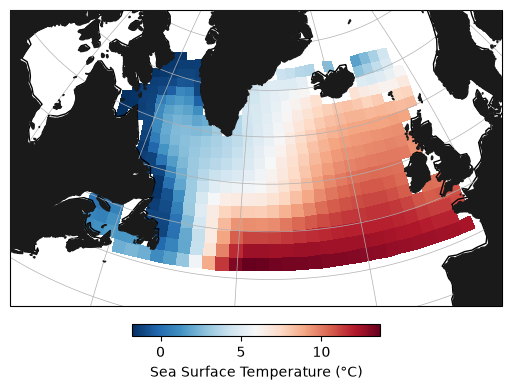

In [20]:
# Define subpolar North Atlantic boundary box for analysis:
bbox_spna = (-68, -2, 45, 67)  # (-68°E, -2°E, 45°N, 67°N)

# Plot the sea surface temperature (°C) in the subpolar North Atlantic region:
(nemo["gridT/tos"]
 .clip(bbox_spna)
 .isel(time_counter=0)
 .geoplot(projection=ccrs.Orthographic(central_longitude=-35, central_latitude=50),
          extent=(-75, 0, 42, 70), # (-75°E, -0°E, 42°N, 70°N)
          cmap='RdBu_r',
          clabel_kwargs={'label': 'Sea Surface Temperature (°C)'}
          )
 )

* To define a regional mask using the geographical coordinates of a closed polygon, we can use the `mask_with_polygon()` method.

* In this example, we use the IHO World Seas v3 Labrador Sea polygon to generate the longitude and latitude coordinates of the closed polygon to mask.

In [21]:
# Open IHO World Seas v3 polygons from JASMIN Object Store as Pandas DataFrame:
filepaths = ncb.examples.get_filepaths("IHO")

df_IHO_World_Seas = pd.read_parquet(filepaths['IHO_World_Seas_v3_polygons.parquet'])


# Define IHO World Seas Labrador Sea polygon:
lon_poly = df_IHO_World_Seas[df_IHO_World_Seas['Name'] == 'Labrador Sea']['Longitudes'].item()[0]
lat_poly = df_IHO_World_Seas[df_IHO_World_Seas['Name'] == 'Labrador Sea']['Latitudes'].item()[0]

# Define boolean mask for Labrador Sea:
LSea_mask = nemo.mask_with_polygon(grid='gridT', lon_poly=lon_poly, lat_poly=lat_poly)

LSea_mask

<xarray.DataArray (j: 148, i: 180)> Size: 27kB
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(148, 180))
Dimensions without coordinates: j, i

* Next, let's create a plot applying our regional mask to a given `NEMODataArray` variable using the `apply_mask()` method.

**Note that using `apply_mask()` is preferred over `where()` since this automatically applies the appropriate land-sea mask in addition to our custom mask**

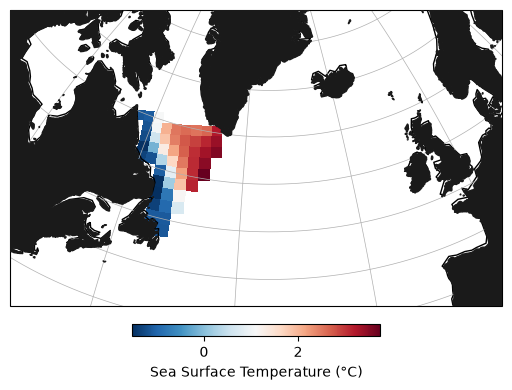

In [22]:
# Plotting Labrador Sea sub-domain sea surface temperature:
(nemo['gridT/tos']
 .isel(time_counter=0)
 .apply_mask(LSea_mask)
 .geoplot(projection=ccrs.Orthographic(central_longitude=-35, central_latitude=50),
          extent=(-75, 0, 42, 70), # (-75°E, -0°E, 42°N, 70°N)
          cmap='RdBu_r',
          clabel_kwargs={'label': 'Sea Surface Temperature (°C)'}
          )
 )


* For more details on clipping grids and domains within a `NEMODataTree` see the following section of the [**How To... Guide**](https://noc-msm.github.io/nemo_cookbook/howto/#clip-a-nemo-model-grid).

#### **Grid Operators**

---

* Grid operators are the foundational set of finite difference operators defined on the NEMO model grid.

* For example, the difference operator $\delta_{i} [q]$ defined by:

$$\delta_{i} [q] = q(i + 1/2) - q(i - 1/2)$$

* For a complete list of grid operators implemented in NEMO Cookbook, see the following sections of the [**How To... Guide**](https://noc-msm.github.io/nemo_cookbook/howto/#calculate-horizontal-derivatives).

* Here, we will focus on the `integral()` method, which can be used to integrate a variable `var` along one or more dimensions `dims` of a given NEMO model grid `grid`.

* As an example, let's compute the total sea ice area in the Northern Hemisphere...

In [23]:
# Define mask for Northern Hemisphere (i.e, > 0°N):
mask_NH = nemo["gridT/gphit"].data > 0

(nemo["gridT/siconc"]
 # Apply Northern Hemisphere mask:
 .apply_mask(mask=mask_NH)
 # Calculate area integral of sea ice concentration (fraction of unity -> m²):
 .integral(dims=["i", "j"])
 # Return the sea ice area values:
 .values
 )

array([1.16388439e+13, 1.24394354e+13])

* We can also use the `.integral()` method to calculate cumulative integrals along one or more dimensions of a given NEMO model grid.

* For more details on cumulative integration see the following section of the [**How To... Guide**](https://noc-msm.github.io/nemo_cookbook/howto/#calculate-cumulative-integrals).

#### **Grid Transformations**
---

* Given that scalar and vector NEMO output variables are not co-located on the model grid, we often need to transform a variable defined on a given NEMO horizontal grid to a neighbouring grid via linear interpolation.

* For example, we can transform the seawater potential temperature `thetao` defined on scalar **T**-points to neighbouring **V**-points in a NEMO model parent domain using the `.interp_to()` method:

In [24]:
nemo['gridT/thetao'].interp_to(to='V')

<NEMODataTree 'NEMO model'>
  <NEMODataArray 'thetao' (Domain: '.', Grid: 'gridV', Grid Type: 'V')>

<xarray.DataArray 'thetao' (time_counter: 2, k: 31, j: 148, i: 180)> Size: 13MB
dask.array<where, shape=(2, 31, 148, 180), dtype=float64, chunksize=(1, 31, 148, 180), chunktype=numpy.ndarray>
Coordinates:
  * time_counter  (time_counter) object 16B 0001-01-03 12:00:00 0001-01-08 12...
  * k             (k) int64 248B 1 2 3 4 5 6 7 8 9 ... 24 25 26 27 28 29 30 31
  * depthv        (k) float32 124B 5.0 15.0 25.0 ... 4.251e+03 4.75e+03 5.25e+03
  * j             (j) float64 1kB 1.5 2.5 3.5 4.5 ... 145.5 146.5 147.5 148.5
  * i             (i) int64 1kB 1 2 3 4 5 6 7 8 ... 174 175 176 177 178 179 180
    gphiv         (j, i) float64 213kB -77.98 -77.98 -77.98 ... 51.91 51.2 50.52
    glamv         (j, i) float64 213kB 80.0 82.0 84.0 86.0 ... 80.21 80.17 80.11
Attributes:
    standard_name:       sea_water_potential_temperature
    long_name:           temperature
    units:               degC
    online_operation:    instant
    interval_operation:  5 d
    interval_write:      5 d
    cell_methods:        time: point

**Note that the original T-grid coordinate variables have been replaced by those of the V-grid onto which the conservative temperature field has been linearly interpolated.**

* We can also transform a variable defined on a given NEMO model vertical grid to a new vertical grid using conservative interpolation via the `.transform_vertical_grid()` method.

* For more details on vertical grid transformations see the following section of the [**How To... Guide**](https://noc-msm.github.io/nemo_cookbook/howto/#interpolate-variable-to-a-neighbouring-horizontal-grid).

#### **Statistics**
---

* Finally, we often want to calculate grid-aware statistics, such as area-weighted averages, using our NEMO model outputs.

* Here, we leverage method chaining and the `weighted_mean()` method to calculate the horizontal grid cell area-weighted average sea surface temperature in the Northern Hemisphere:

In [25]:
# Calculate the area weighted-mean sea surface temperature in the Labrador Sea:
(nemo["gridT/tos"]
 # Apply Labrador Sea mask:
 .apply_mask(LSea_mask)
 # Compute area weighted-mean of sea surface temperature (°C):
 .weighted_mean(dims=["i", "j"])
 # Return the sea surface temperature values:
 .values
 )

array([1.09300028, 0.7893101 ])

* We can also calculate aggregated statistics of a variable binned according to the values of one or more variables using the `NEMODataTree.binned_statistic()` method.

* For more details on statistical methods see the following section of the [**How To... Guide**](https://noc-msm.github.io/nemo_cookbook/howto/#calculate-statistics-for-a-region-masked-using-a-polygon).